# Análise Exploratória e Preparação de Dados: Classificação de Score de Crédito

## Contexto

Bancos e financeiras classificam seus clientes em faixas de score de crédito para decidir quem recebe crédito, com qual limite e a qual taxa de juros. Um score bem estimado reduz inadimplência e evita recusar bons clientes.

Neste projeto, faço a **análise exploratória (EDA) e a preparação dos dados** de um dataset de clientes de um banco. O objetivo final é deixar a base pronta para treinar, em uma etapa seguinte, um modelo que classifique cada cliente em **Good**, **Standard** ou **Poor**.

## Objetivos

1. Entender a estrutura e a qualidade dos dados.
2. Limpar valores corrompidos, nulos e inconsistentes.
3. Investigar quais variáveis mais se relacionam com o score de crédito.
4. Criar novas variáveis (*feature engineering*) com significado financeiro.
5. Exportar um dataset limpo (`clean_train.csv`) para a modelagem.

## Sobre os dados

- Arquivo `train.csv`, com **100.000 registros e 28 colunas**.
- Cada linha é o retrato mensal de um cliente (janeiro a agosto), com informações demográficas (idade, profissão), financeiras (renda, dívida, número de cartões e contas) e de comportamento de pagamento (atrasos, consultas de crédito, pagamento mínimo).
- A variável-alvo é `Credit_Score`, com três classes: `Good`, `Standard` e `Poor`.
- É um dataset público do Kaggle ("Credit Score Classification") e contém muito ruído: valores absurdos, textos no lugar de números, símbolos estranhos e campos nulos. Boa parte do trabalho está em lidar com isso.

### Importando bibliotecas

Utilizo `pandas` e `numpy` para manipulação dos dados, `seaborn` e `matplotlib` para os gráficos, e o `OrdinalEncoder` do `scikit-learn` para transformar categorias em números mais adiante.

In [101]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import OrdinalEncoder
import kagglehub

### Carregando os dados

In [102]:
file_path = Path('../data/train.csv')
    
if file_path.exists():
    print(f"O dataset já está baixado em: {file_path}")
else:
    path: str = kagglehub.dataset_download(
        "parisrohan/credit-score-classification",
        output_dir='../data/',
        path='train.csv'
    )
    print(f"Dados guardados em: {path}")

O dataset já está baixado em: ../data/train.csv


Os dados são lidos a partir do arquivo `train.csv`. O aviso `DtypeWarning` já indica que a coluna `Monthly_Balance` mistura tipos (números e texto), um primeiro sinal de que existem valores corrompidos que precisarão ser tratados.

In [103]:
pd.set_option('display.max_columns', None)

In [104]:
df = pd.read_csv('../data/train.csv')
df.head()

/tmp/ipykernel_55004/4111262129.py:1: DtypeWarning: Columns (26: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


### Visão geral dos dados

O `df.info()` mostra o tipo e a quantidade de valores não nulos de cada coluna. Dois pontos chamam atenção:

- Várias colunas que deveriam ser numéricas (como `Age`, `Annual_Income`, `Num_of_Loan`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit` e `Outstanding_Debt`) foram lidas como texto, provavelmente por conterem caracteres indevidos.
- Há nulos em colunas como `Name`, `Monthly_Inhand_Salary`, `Type_of_Loan`, `Num_of_Delayed_Payment`, `Num_Credit_Inquiries` e `Credit_History_Age`.

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

Removo as colunas `ID` e `SSN`. São identificadores, sem valor preditivo para o score, e o `SSN` ainda é um dado sensível que não deveria alimentar um modelo.

In [106]:
df = df.drop(['ID', 'SSN'], axis=1)

In [107]:
print(f'Numero de linhas: {df.shape[0]}')
print(f'Numero de colunas: {df.shape[1]}')

Numero de linhas: 100000
Numero de colunas: 26


In [108]:
print(f'Numero de entradas nulas: {df.isnull().sum().sum()}')

Numero de entradas nulas: 60071


In [109]:
print(f'Numero de entradas duplicadas: {df.duplicated().sum()}')

Numero de entradas duplicadas: 0


**Resumo da checagem inicial:** a base tem 100.000 linhas e 26 colunas restantes, **60.071 valores nulos** e **nenhuma linha duplicada**. Como não há duplicatas, o próximo passo é lidar com os nulos.

In [110]:
round(df.describe(), 2)

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.00,100000.00,100000.00,100000.00,100000.00,98035.00,100000.00,100000.00
mean,4194.17,17.09,22.47,72.47,21.07,27.75,32.29,1403.12
std,3183.69,117.40,129.06,466.42,14.86,193.18,5.12,8306.04
min,303.65,-1.00,0.00,1.00,-5.00,0.00,20.00,0.00
25%,1625.57,3.00,4.00,8.00,10.00,3.00,28.05,30.31
50%,3093.75,6.00,5.00,13.00,18.00,6.00,32.31,69.25
75%,5957.45,7.00,7.00,20.00,28.00,9.00,36.50,161.22
max,15204.63,1798.00,1499.00,5797.00,67.00,2597.00,50.00,82331.00


O `describe()` revela inconsistências claras:

- `Num_Bank_Accounts` tem máximo de 1.798 e mínimo de -1.
- `Num_Credit_Card` chega a 1.499.
- `Interest_Rate` chega a 5.797 (%), o que não é plausível.
- `Num_Credit_Inquiries` chega a 2.594.
- `Delay_from_due_date` tem valores negativos.

Ou seja, além dos nulos, há **outliers extremos e valores impossíveis** que também precisam de tratamento.

In [111]:
df['Age'] = df['Age'].astype(str).str.rstrip('_').astype(int)

for name in df['Name'].unique():
    ages = df.loc[df['Name'] == name, 'Age'].unique()

    valid_ages = ages[(ages >= 0) & (ages <= 100)]

    if len(valid_ages) == 0:
        continue  

    replacement = int(np.median(valid_ages)) 

    invalid_mask = (df['Name'] == name) & ((df['Age'] < 0) | (df['Age'] > 100))
    df.loc[invalid_mask, 'Age'] = replacement

**Correção das idades.** O código faz duas coisas:

1. Remove o caractere `_` que aparece no final de alguns valores e converte a coluna para inteiro.
2. Para cada cliente (agrupando pelo nome), calcula a **mediana das idades válidas** (entre 0 e 100) e usa esse valor para substituir as idades inválidas dele.

Como a idade de uma pessoa não muda ao longo de 8 meses, essa abordagem é mais confiável do que usar a média geral da base.

In [112]:
nomes_suspeitos = []
for name in df['Name'].unique():
    ages = df.loc[df['Name'] == name, 'Age'].unique()

    valid_ages = ages[(ages >= 0) & (ages <= 100)]
    
    if len(valid_ages) != len(ages):
        nomes_suspeitos.append(name)

nomes_suspeitos

[]

Depois da correção, procuro clientes que **ainda têm idades inválidas**, ou seja, aqueles para os quais não existe nenhuma idade válida para servir de referência. Foram três: `Wheatleyi`, `Michele Kambasi` e `Philh`.

In [113]:
df.loc[df['Name'].isin(nomes_suspeitos)]

,Customer_ID,Month,Name,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score


Como não há como recuperar a idade real desses três clientes, eles são removidos da base.

In [114]:
df = df.loc[~df['Name'].isin(nomes_suspeitos)]

##### Distribuição das classes

In [115]:
df['Credit_Score'].value_counts(normalize=True) * 100

Credit_Score
Standard    53.174
Poor        28.998
Good        17.828
Name: proportion, dtype: float64

**Distribuição das classes.** A base é **desbalanceada**: cerca de 52,7% dos registros são `Standard`, 31,1% são `Poor` e apenas 16,2% são `Good`.

Isso importa para a modelagem: um modelo que sempre prevesse `Standard` já acertaria mais da metade dos casos.

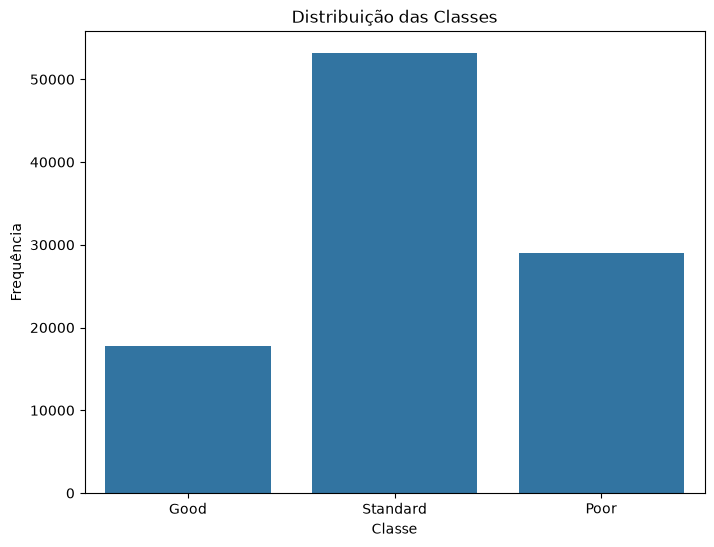

In [116]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Credit_Score', data=df)
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()

A coluna `Name` não terá mais relevância na análise, podemos desconsiderá-la.

In [117]:
df = df.drop('Name', axis=1)

Classificamos as variáveis restantes

In [118]:
df.columns

Index(['Customer_ID', 'Month', 'Age', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='str')

#### Transformando `Credit_History_Age` em número

A coluna traz textos como `"22 Years and 1 Months"`. Com uma expressão regular, extraio os anos e os meses e converto tudo para **anos em formato decimal** (por exemplo, 22 anos e 3 meses viram 22,25). A coluna original é descartada e a nova se chama `Credit_History_Age_Years`.

In [119]:
extracted = df['Credit_History_Age'].str.extract(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?')
df['Credit_History_Age_Years'] = (
    extracted[0].astype(float) + extracted[1].astype(float) / 12
)
df = df.drop(columns=['Credit_History_Age'])

#### Separando variáveis categóricas e numéricas

Defino manualmente quais colunas são categóricas. Todas as demais são tratadas como numéricas.

In [120]:
CATEGORICAL_COLUMNS = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

NUMERICAL_COLUMNS = df.drop(CATEGORICAL_COLUMNS, axis=1).columns.to_list()
NUMERICAL_COLUMNS.remove('Customer_ID')

#### Procurando valores placeholder nas categóricas

Ao listar os valores únicos, aparecem marcadores de dado ausente disfarçados de categoria, como `_______` em `Occupation`, `_` em `Credit_Mix` e `NM` em `Payment_of_Min_Amount`. O `isnull()` não detecta esses casos, por isso eles passaram despercebidos até aqui.

In [121]:
unique_values = {col: df[col].unique().tolist() for col in CATEGORICAL_COLUMNS}

print(f'Valores unicos em "Occupation": {unique_values['Occupation']}')
print(f'Valores unicos em "Credit_Mix": {unique_values['Credit_Mix']}')
print(f'Valores unicos em "Payment_of_Min_Amount": {unique_values['Payment_of_Min_Amount']}')
print(f'Valores unicos em "Payment_Behaviour": {unique_values['Payment_Behaviour']}')

Valores unicos em "Occupation": ['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect']
Valores unicos em "Credit_Mix": ['_', 'Good', 'Standard', 'Bad']
Valores unicos em "Payment_of_Min_Amount": ['No', 'NM', 'Yes']
Valores unicos em "Payment_Behaviour": ['High_spent_Small_value_payments', 'Low_spent_Large_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'High_spent_Medium_value_payments', '!@9#%8', 'High_spent_Large_value_payments']


In [122]:
print(df.loc[(df['Occupation'] == '_______')].shape[0])
print(df.loc[(df['Credit_Mix'] == '_')].shape[0])
print(df.loc[(df['Payment_of_Min_Amount'] == 'NM')].shape[0])

7062
20195
12007


Contagem dos placeholders: 3.727 linhas em `Occupation`, 10.693 em `Credit_Mix` e 6.346 em `Payment_of_Min_Amount`.

In [123]:
moda_occupation = df["Occupation"].mode()[0] # Sera removida!
moda_credit_mix = df["Credit_Mix"].mode()[0]
moda_payment = df["Payment_of_Min_Amount"].mode()[0]

print(moda_occupation)
print(moda_credit_mix)
print(moda_payment)

_______
Standard
Yes


Substituo os placeholders pela **moda** (valor mais frequente) em `Credit_Mix` e `Payment_of_Min_Amount`.

Em `Occupation` a moda é o próprio placeholder (`_______`), então a imputação não faz sentido e foi deixada comentada. Isso não é um problema, porque, como veremos na análise, essa coluna é descartada por não ajudar a separar as classes.

In [124]:
# df.loc[(df['Occupation'] == '_______')] = moda_occupation
df.loc[(df['Credit_Mix'] == '_'), 'Credit_Mix'] = moda_credit_mix
df.loc[(df['Payment_of_Min_Amount'] == 'NM'), 'Payment_of_Min_Amount'] = moda_payment

#### Limpando as colunas numéricas

Remove o `_` residual no final dos valores e converte tudo para número com `pd.to_numeric(errors='coerce')`. Valores que continuam impossíveis de converter (como `__10000__`) viram nulos, que serão tratados na sequência.

In [125]:
for col in NUMERICAL_COLUMNS:
    df[col] = df[col].astype(str).str.rstrip('_')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [126]:
df.isnull().sum()

Customer_ID                     0
Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      8784
Payment_Behaviour               0
Monthly_Balance              1209
Credit_Score                    0
Credit_History_Age_Years     9030
dtype: int64

In [127]:
moda_changed_credit = df["Changed_Credit_Limit"].mode()[0]
moda_inquiries = df["Num_Credit_Inquiries"].mode()[0]
moda_loan_type = df["Type_of_Loan"].mode()[0]
moda_delayed = df["Num_of_Delayed_Payment"].mode()[0]

media_salary = df["Monthly_Inhand_Salary"].mean()
media_invested = df["Amount_invested_monthly"].mean()
media_balance = df["Monthly_Balance"].mean()
media_history = df["Credit_History_Age_Years"].mean()

df.loc[df["Credit_History_Age_Years"].isna(), 'Credit_History_Age_Years'] = media_history
df.loc[df["Num_Credit_Inquiries"].isna(), 'Num_Credit_Inquiries'] = moda_inquiries
df.loc[df["Num_of_Delayed_Payment"].isna(), 'Num_of_Delayed_Payment'] = moda_delayed
df.loc[df["Type_of_Loan"].isna(), 'Type_of_Loan'] = moda_loan_type
df.loc[df["Changed_Credit_Limit"].isna(), 'Changed_Credit_Limit'] = moda_changed_credit

df.loc[df["Monthly_Inhand_Salary"].isna(), 'Monthly_Inhand_Salary'] = media_salary
df.loc[df["Amount_invested_monthly"].isna(), 'Amount_invested_monthly'] = media_invested
df.loc[df["Monthly_Balance"].isna(), 'Monthly_Balance'] = media_balance

In [128]:
df.isnull().sum()

Customer_ID                 0
Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Credit_History_Age_Years    0
dtype: int64

#### Tratando outliers

Para as variáveis com valores absurdos vistos no `describe()`, uso um corte no **percentil 98**: linhas com valor acima desse limite em qualquer uma dessas colunas são removidas. É uma forma simples e transparente de eliminar os extremos sem precisar definir um limite manual para cada variável.

In [129]:
CUTOFF_VARIABLES = [
    'Monthly_Inhand_Salary', 
    'Num_Bank_Accounts', 
    'Num_Credit_Card', 
    'Interest_Rate', 
    'Delay_from_due_date', 
    'Num_Credit_Inquiries', 
    'Total_EMI_per_month'
]

In [130]:
cutoff_values = df[CUTOFF_VARIABLES].quantile(0.98)

for column in CUTOFF_VARIABLES:
    cutoff = cutoff_values[column]
    df = df.loc[df[column] <= cutoff]

In [131]:
df.shape

(87535, 25)

---
## Análise exploratória

#### Correlação entre as variáveis numéricas

O heatmap mostra apenas o triângulo inferior da matriz de correlação (a escala de cores foi limitada em 0,3 para destacar melhor as relações).

O que se observa:

- Um grupo de variáveis anda junto: `Num_Bank_Accounts`, `Interest_Rate`, `Delay_from_due_date`, `Changed_Credit_Limit`, `Num_Credit_Inquiries` e `Outstanding_Debt` têm correlações positivas entre si. Elas representam, em conjunto, um perfil de **maior risco**.
- `Credit_History_Age_Years` tem correlação negativa com esse mesmo grupo: quanto mais longo o histórico, menos contas, menos atrasos, menos consultas e menos dívida.
- `Monthly_Balance` e `Monthly_Inhand_Salary` se relacionam de forma oposta ao grupo de risco.
- `Age`, `Annual_Income`, `Num_of_Loan` e `Num_of_Delayed_Payment` mal se correlacionam com as demais.

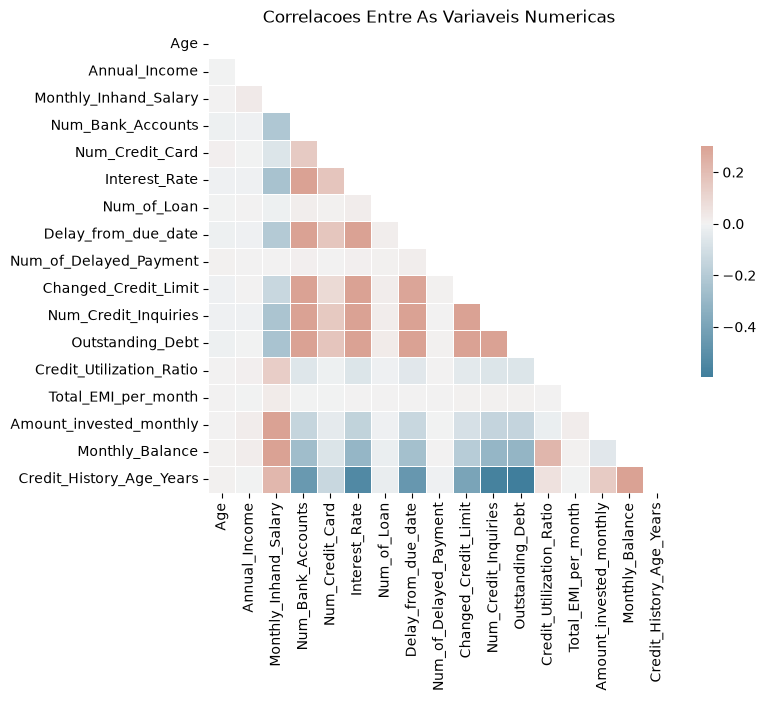

In [132]:
correlation = df.drop('Customer_ID', axis=1).drop(CATEGORICAL_COLUMNS, axis=1).corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
f, ax = plt.subplots(figsize=(8, 6))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(correlation, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlacoes Entre As Variaveis Numericas')
plt.show()

#### Variáveis numéricas × Credit Score

Um boxplot para cada variável numérica, separado por classe de score. A ideia é identificar quais variáveis **realmente diferenciam** um cliente `Good` de um `Poor`.

Variáveis que separam bem as classes:

- `Delay_from_due_date`: a mediana de atraso é de cerca de 10 dias para `Good` e cerca de 27 para `Poor`.
- `Num_Credit_Inquiries`: mediana perto de 3 para `Good` e perto de 9 para `Poor`.
- `Outstanding_Debt`: mediana perto de 750 para `Good` e perto de 2.000 para `Poor`.
- `Num_Bank_Accounts` e `Interest_Rate`: crescem do `Good` para o `Poor`.
- `Credit_History_Age_Years`: clientes `Good` têm históricos bem mais longos (mediana perto de 24 anos, contra cerca de 13 dos `Poor`).
- `Monthly_Inhand_Salary` e `Monthly_Balance`: valores mais altos entre os clientes `Good`.

Variáveis que separam pouco: `Credit_Utilization_Ratio` tem distribuição praticamente igual nas três classes, e `Changed_Credit_Limit` e `Amount_invested_monthly` têm diferenças pequenas. Outras variáveis, como `Annual_Income`, `Num_of_Loan` e `Num_of_Delayed_Payment`, ainda exibem outliers extremos que esmagam a escala do gráfico.

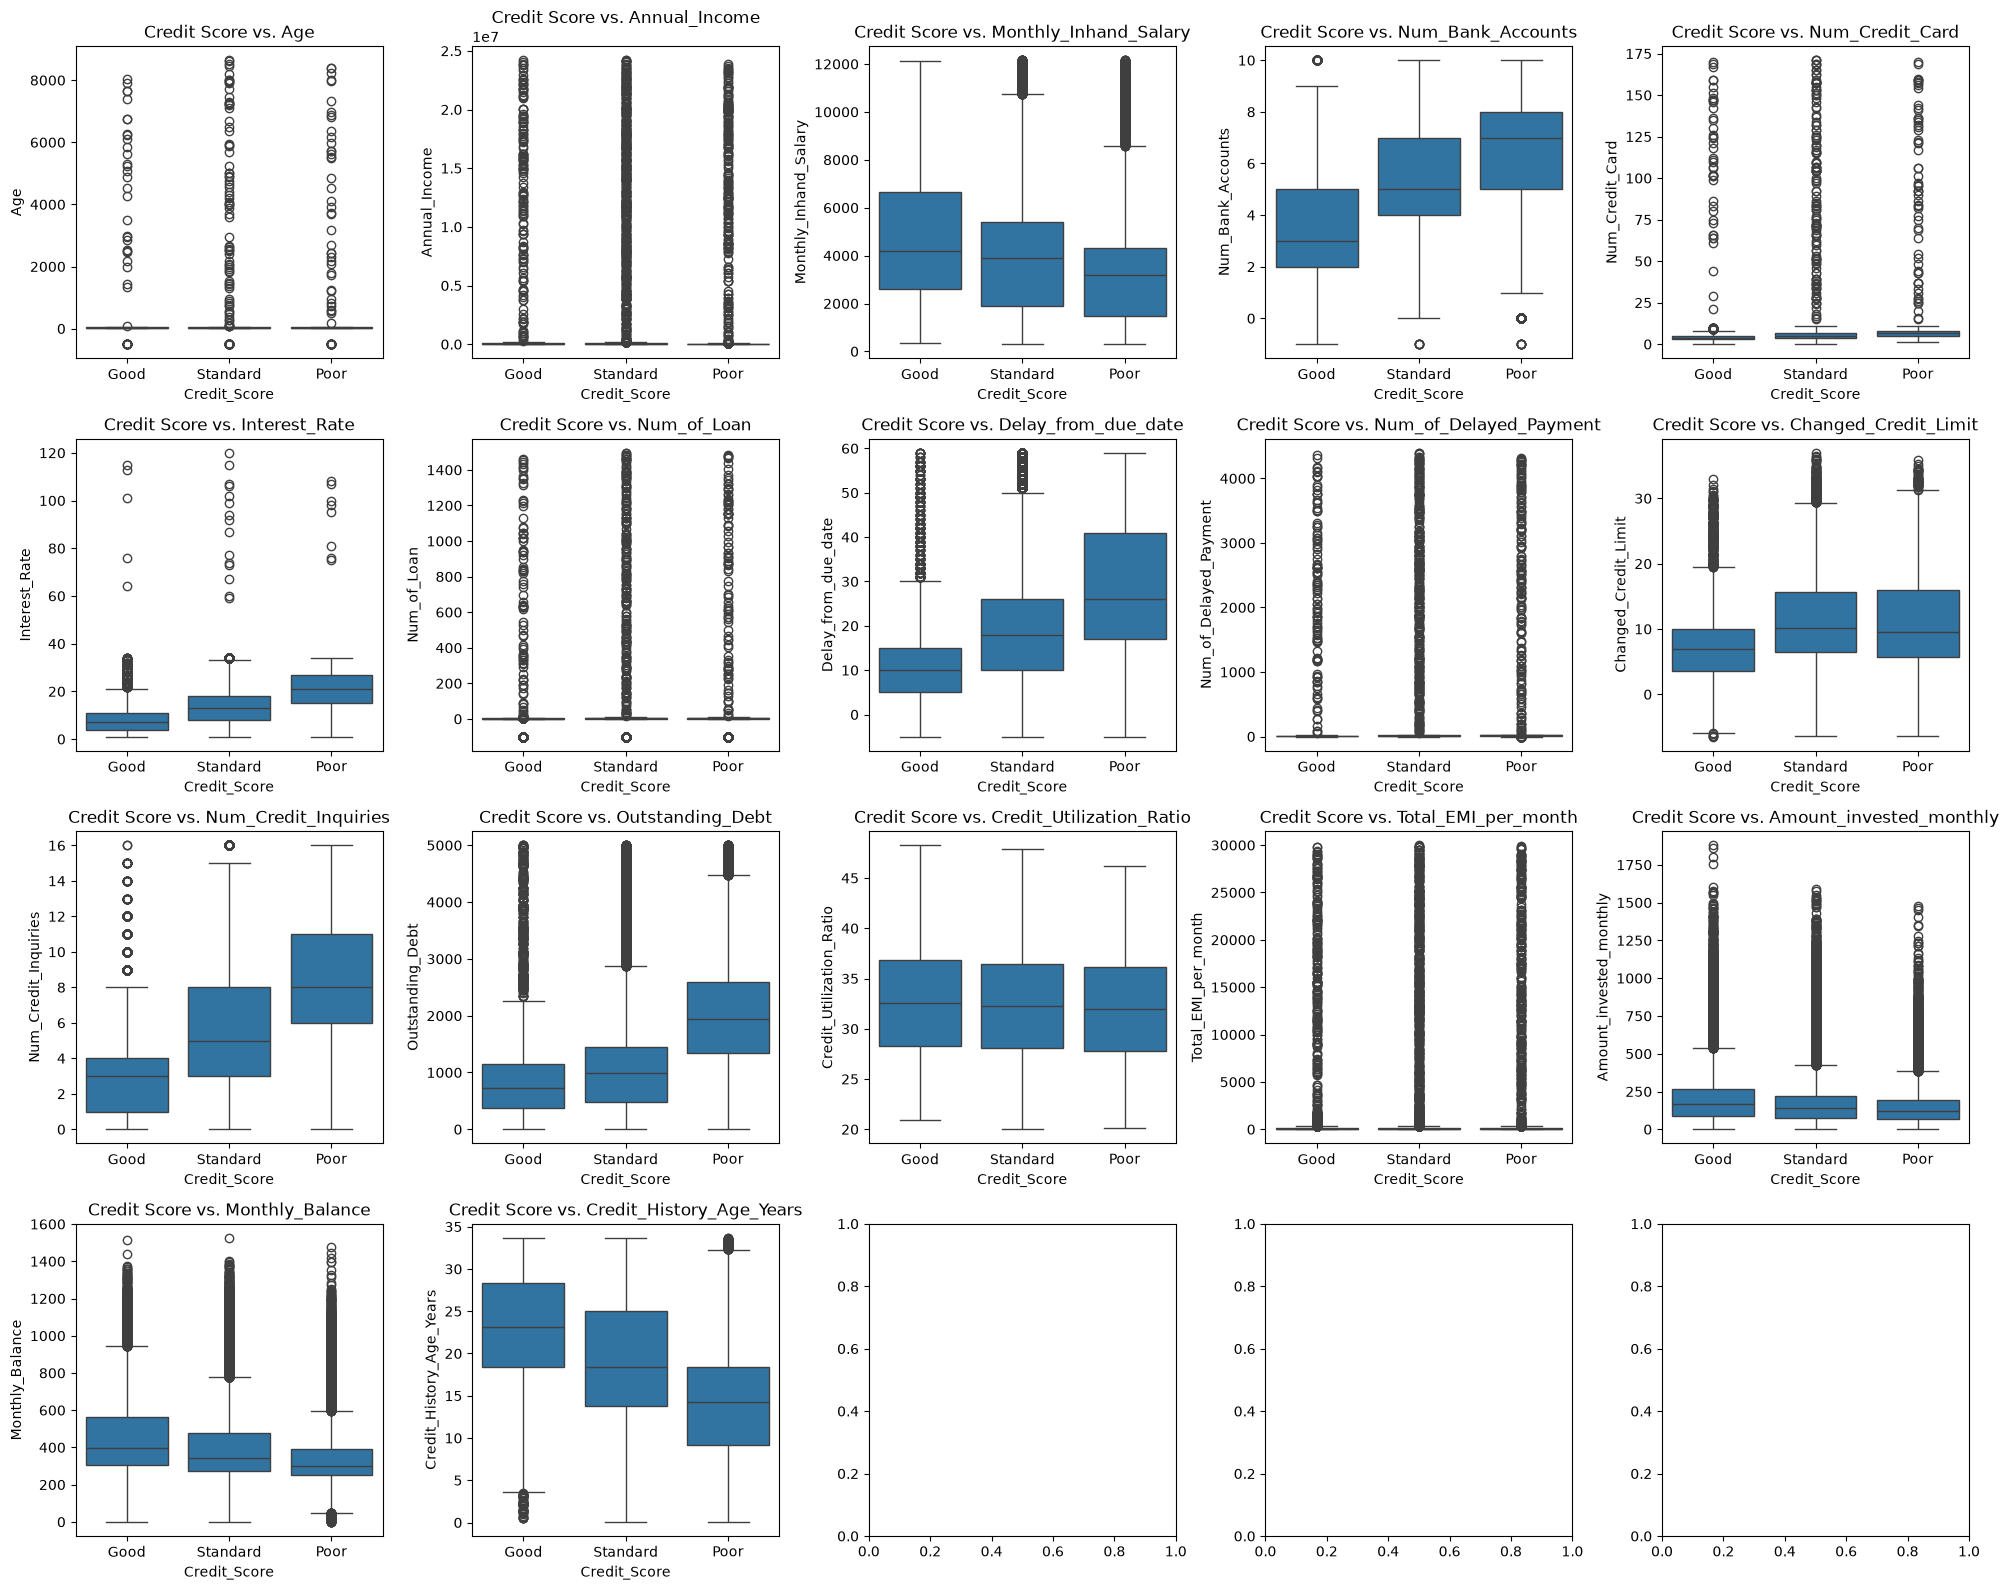

In [133]:
f, ax = plt.subplots(ncols=5, nrows=4, figsize=(20, 16))
ax = ax.flatten() 

for i, column in enumerate(NUMERICAL_COLUMNS):
    sns.boxplot(x='Credit_Score', y=column, data=df, ax=ax[i])
    ax[i].set_title(f'Credit Score vs. {column}')

plt.tight_layout()
plt.show()

#### Variáveis categóricas × Credit Score

Para as categóricas, uso tabelas cruzadas normalizadas por classe (cada linha soma 100%) e as exibo como heatmaps. Assim é possível ver, dentro de cada classe de score, qual a proporção de cada categoria. Uma variável só é útil se as linhas do heatmap forem visivelmente diferentes entre si.

In [134]:
GOOD_CATEGORICAL_VARIABLES = [
    'Month',
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

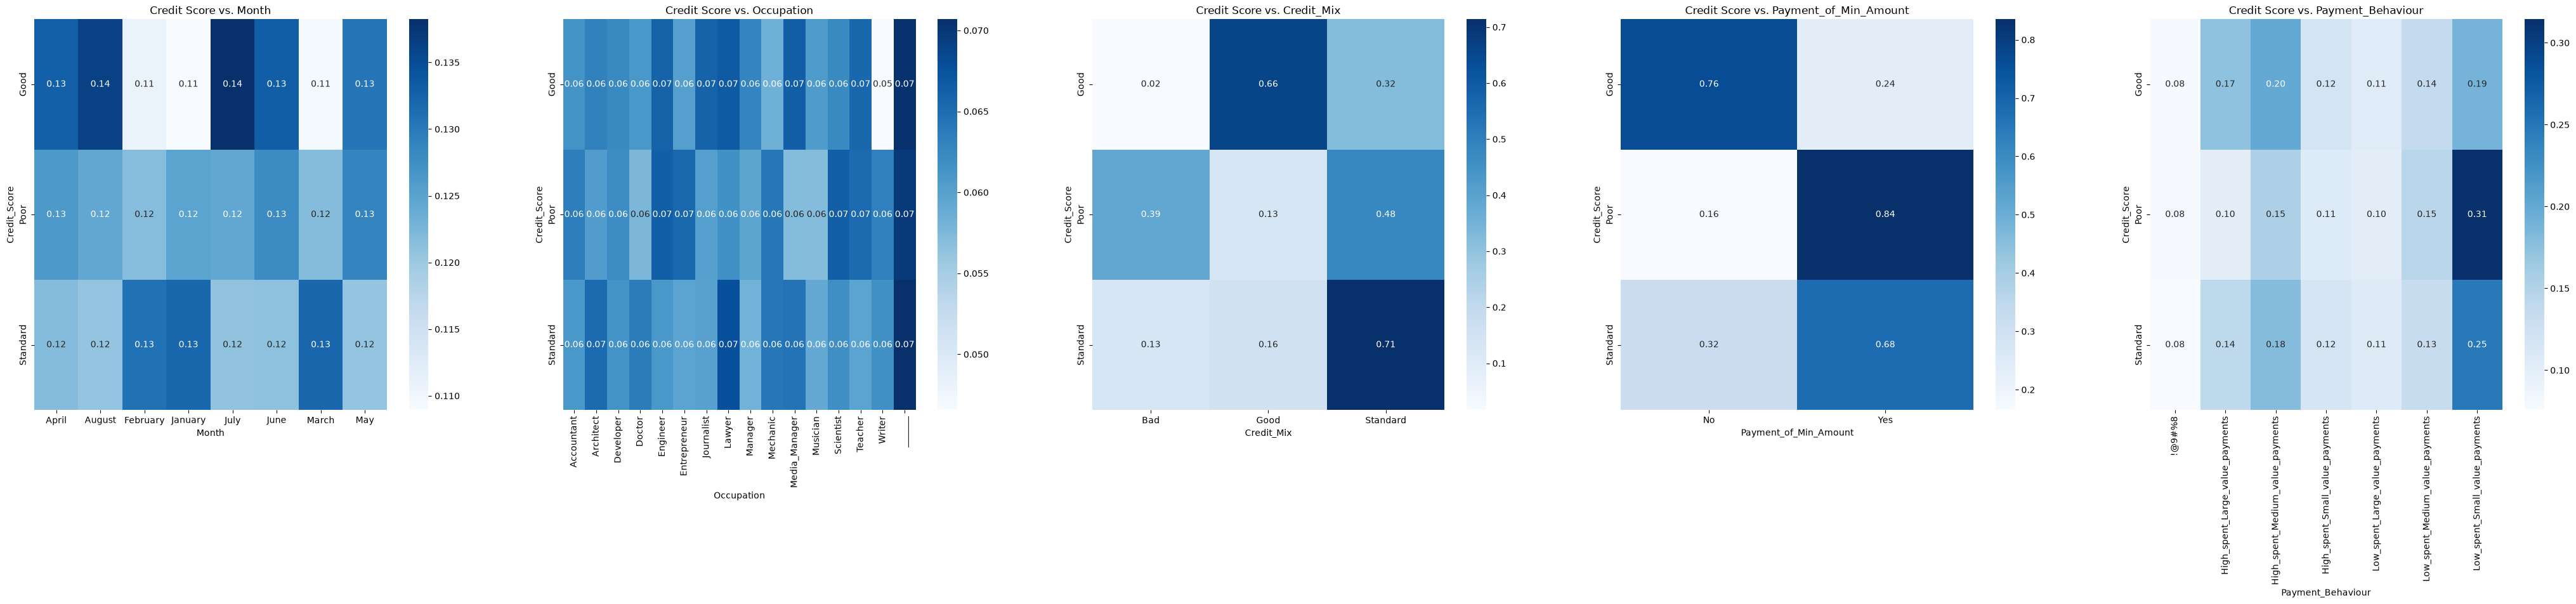

In [135]:
f, ax = plt.subplots(ncols=5, figsize=(52, 8))

for i, column in enumerate(GOOD_CATEGORICAL_VARIABLES):
    tabela = pd.crosstab(df['Credit_Score'], df[column], normalize='index')
    sns.heatmap(tabela, annot=True, cmap='Blues', fmt='.2f', ax=ax[i])
    ax[i].set_title(f'Credit Score vs. {column}')

plt.show()

**O que os heatmaps mostram:**

- `Credit_Mix` é muito informativo: 65% dos clientes `Good` têm mix `Good`, enquanto 40% dos `Poor` têm mix `Bad`.
- `Payment_of_Min_Amount` também: 87% dos clientes `Poor` pagam apenas o mínimo, contra 25% dos `Good`.
- `Payment_Behaviour` ajuda em parte: o padrão "gasta pouco, com pagamentos de valor baixo" aparece em 31% dos `Poor` e 19% dos `Good`.
- `Month` e `Occupation` têm distribuições praticamente idênticas entre as classes, ou seja, **não ajudam a explicar o score**.

#### Seleção de variáveis

Com base na análise visual, mantenho as variáveis que mostraram relação com o score e descarto as demais (`Age`, `Annual_Income`, `Occupation`, `Month`, `Num_of_Loan`, `Num_of_Delayed_Payment`, `Type_of_Loan`, `Changed_Credit_Limit`, `Credit_Utilization_Ratio` e `Amount_invested_monthly`). O dataset final passa a ter **15 colunas**, incluindo o alvo.

É uma seleção baseada em inspeção visual e julgamento. Numa etapa de modelagem, ela pode ser validada com métodos como importância de variáveis.

In [136]:
GOOD_VARIABLES = [
    'Customer_ID',
    'Total_EMI_per_month',
    'Monthly_Inhand_Salary',
    'Monthly_Balance',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_History_Age_Years',
    'Credit_Score'
]

In [137]:
df = df[GOOD_VARIABLES]

In [138]:
df.shape

(87535, 15)

In [139]:
for column in df.columns:
    if df[column].dtype == 'str':
        print(f'A coluna {column} tem {len(df[column].unique())} variaveis diferentes')

A coluna Customer_ID tem 12309 variaveis diferentes
A coluna Credit_Mix tem 3 variaveis diferentes
A coluna Payment_of_Min_Amount tem 2 variaveis diferentes
A coluna Payment_Behaviour tem 7 variaveis diferentes
A coluna Credit_Score tem 3 variaveis diferentes


#### Codificando as variáveis categóricas

Modelos de machine learning precisam de números, então uso o `OrdinalEncoder` para converter as colunas de texto (`Credit_Mix`, `Payment_of_Min_Amount`, `Payment_Behaviour` e `Credit_Score`) em códigos inteiros.

Um detalhe importante: o encoder atribui os códigos em ordem alfabética. No alvo, isso resulta em **Good = 0, Poor = 1 e Standard = 2**, o que não reflete a ordem real de qualidade (Poor < Standard < Good). Para a modelagem, vale definir a ordem explicitamente ou tratar o problema como classificação multiclasse sem ordem.

In [140]:
colunas_texto = df.select_dtypes(include='string').columns.tolist()
colunas_texto.remove('Customer_ID')

In [141]:
oe = OrdinalEncoder()
df[colunas_texto] = oe.fit_transform(df[colunas_texto])

#### Valores negativos remanescentes

Verifico se ainda existem valores negativos, que não fazem sentido para estas variáveis (por exemplo, `Num_Bank_Accounts = -1` e atrasos negativos). Em seguida, substituo esses valores por `NaN`, para não contaminarem as próximas etapas. Alguns nulos voltam a existir na base como consequência, e são poucos (algumas centenas).

In [142]:
df.loc[(df.drop('Customer_ID', axis=1) < 0).any(axis=1)]

,Customer_ID,Total_EMI_per_month,Monthly_Inhand_Salary,Monthly_Balance,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Outstanding_Debt,Credit_History_Age_Years,Credit_Score
1,CUS_0xd40,49.574949,4194.170850,284.629162,1.0,0.0,4.0,3,4,3,-1,4.0,809.98,18.432950,0.0
49,CUS_0x284a,137.644605,11242.783333,547.760457,1.0,0.0,3.0,0,1,8,-1,4.0,352.16,30.666667,0.0
74,CUS_0xba08,46.616129,2825.233333,375.086508,1.0,0.0,5.0,1,6,12,-2,5.0,421.43,26.583333,0.0
78,CUS_0xba08,46.616129,2825.233333,337.512304,1.0,0.0,6.0,1,6,12,-1,5.0,421.43,26.916667,0.0
79,CUS_0xba08,46.616129,4194.170850,273.262377,2.0,0.0,6.0,1,6,12,-2,5.0,421.43,27.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99198,CUS_0xb59b,49.656727,7775.935000,854.815150,1.0,0.0,0.0,3,3,1,-2,4.0,1366.21,17.833333,0.0
99358,CUS_0x870c,65.051299,1724.938333,268.415598,2.0,0.0,6.0,2,4,9,-1,9.0,823.21,32.333333,0.0
99368,CUS_0x163c,31.650737,5082.148333,612.047512,1.0,0.0,5.0,2,3,11,-4,0.0,608.87,17.833333,2.0
99371,CUS_0x163c,31.650737,5082.148333,263.420000,2.0,0.0,5.0,2,3,11,-5,2.0,608.87,18.083333,0.0


In [143]:
cols = df.columns.drop('Customer_ID')
df[cols] = df[cols].where(df[cols] >= 0, np.nan)

In [144]:
df['Customer_ID']

0         CUS_0xd40
1         CUS_0xd40
2         CUS_0xd40
3         CUS_0xd40
4         CUS_0xd40
            ...    
99994    CUS_0x942c
99995    CUS_0x942c
99996    CUS_0x942c
99998    CUS_0x942c
99999    CUS_0x942c
Name: Customer_ID, Length: 87535, dtype: str

---
## Feature engineering

Crio variáveis derivadas que combinam informações da base e têm interpretação financeira direta:

| Nova variável | Cálculo | O que representa |
|---|---|---|
| `Debt_per_Card` | Dívida ÷ (nº de cartões + 1) | Quanto de dívida está concentrado em cada cartão |
| `Debt_to_Income` | Dívida ÷ salário mensal | Peso da dívida em relação à renda |
| `EMI_to_Salary` | Parcelas mensais ÷ salário mensal | Quanto da renda é comprometido com parcelas |
| `Balance_to_Salary` | Saldo mensal ÷ salário mensal | Quanto da renda sobra ao final do mês |
| `Interest_x_Delay` | Taxa de juros × dias de atraso | Interação entre juros altos e atrasos |
| `Interest_x_Debt` | Taxa de juros × dívida | Interação entre juros altos e dívida alta |

Razões como as três primeiras costumam ser mais informativas do que os valores absolutos, porque colocam a dívida e as parcelas em perspectiva com a renda de cada cliente.

In [145]:
df["Debt_per_Card"] = df["Outstanding_Debt"] / (df["Num_Credit_Card"] + 1)
df['Interest_x_Delay'] = df['Interest_Rate'] * df['Delay_from_due_date']
df['Interest_x_Debt'] = df['Interest_Rate'] * df['Outstanding_Debt']
df["Debt_to_Income"] = df["Outstanding_Debt"] / df['Monthly_Inhand_Salary']
df["EMI_to_Salary"] = df["Total_EMI_per_month"] / df['Monthly_Inhand_Salary']
df["Balance_to_Salary"] = df["Monthly_Balance"] / df['Monthly_Inhand_Salary']
df["Debt_per_Card"] = df["Outstanding_Debt"] / (df["Num_Credit_Card"] + 1)

In [146]:
df.info()

<class 'pandas.DataFrame'>
Index: 87535 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               87535 non-null  str    
 1   Total_EMI_per_month       87535 non-null  float64
 2   Monthly_Inhand_Salary     87535 non-null  float64
 3   Monthly_Balance           87535 non-null  float64
 4   Credit_Mix                87535 non-null  float64
 5   Payment_of_Min_Amount     87535 non-null  float64
 6   Payment_Behaviour         87535 non-null  float64
 7   Num_Bank_Accounts         87515 non-null  float64
 8   Num_Credit_Card           87535 non-null  int64  
 9   Interest_Rate             87535 non-null  int64  
 10  Delay_from_due_date       87029 non-null  float64
 11  Num_Credit_Inquiries      87535 non-null  float64
 12  Outstanding_Debt          87535 non-null  float64
 13  Credit_History_Age_Years  87535 non-null  float64
 14  Credit_Score          

#### Exportando o dataset limpo

Salvo a base tratada em `clean_train.csv`, pronta para ser usada no treinamento de modelos.

In [147]:
df.to_csv('../data/clean_train.csv', index=False)